In [2]:
!pip install --upgrade  scikit-image==0.25.2

  Using cached scikit_image-0.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
Using cached scikit_image-0.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (14.8 MB)
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.19.3
    Uninstalling scikit-image-0.19.3:
      Successfully uninstalled scikit-image-0.19.3


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants as cst
#import speasy as spz
from datetime import timedelta, datetime, timezone
from matplotlib.colors import LogNorm, SymLogNorm, Normalize
from scipy.ndimage import gaussian_filter as gf
from scipy.interpolate import NearestNDInterpolator
import matplotlib.gridspec as gridspec

from scipy.optimize import fsolve
from math import radians as rad
from math import degrees as deg

from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)


from multiprocessing import Pool 

import sys

#sys.path.append('../../../These/Python_function/spok/')
#sys.path.append('../../../These/Python_function/My_functions/')
sys.path.append('/DATA/michotte/xline/')

from spok.models import planetary as smp
from spok import smath as sm
from spok.coordinates import coordinates as scc
from spok import utils as su
import py_tsyganenko.Geopack as gp
import py_tsyganenko.Models as tm
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar,minimize


from skimage.feature import hessian_matrix,hessian_matrix_eigvals
from scipy.interpolate import griddata

from sklearn.neighbors import KNeighborsRegressor
#import boundaries_models as bm
import shear_maps as smap
import maps_mp_data as mmp
import utilities as uti

#import speasy as spz

from shapely import Point, LineString


#%matplotlib widget

msh = smp.Magnetosheath(magnetopause='mp_shue1998', bow_shock ='bs_jelinek2012')
#msh = smp.Magnetosheath(magnetopause='mp_sibeck1991', bow_shock ='bs_jelinek2012')

In [1]:
! pip install structure_tensor

  Using cached structure_tensor-0.3.4-py3-none-any.whl.metadata (11 kB)
Using cached structure_tensor-0.3.4-py3-none-any.whl (20 kB)


In [9]:

def fig_nxm_plots(n=2,m=2,figsize=None,cmap='seismic',msh=msh):
    mp,bs = msh.boundaries(np.pi/2,np.linspace(0,2*np.pi,50))
    if figsize is None :
        fig,axs = plt.subplots(m,n,figsize=(n*7.,m*6+0.9))
    else :
        fig,axs = plt.subplots(m,n,figsize=(figsize[0],figsize[1]))
    axs = np.asarray(su.listify(axs))
    for ax in axs.ravel():
        ax.plot(mp[1],mp[2],ls='-.',color='k')
        ax.plot(bs[1],bs[2],ls='--',color='k')
        ax.set_aspect('equal')
 
        ax.axhline(0,ls='--',c='k',alpha=0.75)
        ax.axvline(0,ls='--',c='k',alpha=0.75)
        ax.set_xlim(-16,16)
        ax.set_ylim(-16,16)
    
    alphabet = list('abcdefghijklmnopqr')
    apair= alphabet[::2] 
    aimpair= alphabet[1::2] 

    if len(axs.shape)>1:
        cnt = 0
        for i in range(len(axs)):
            axs[i,0].tick_params(axis='both', which='major', labelsize=13)
            axs[i,0].set_ylabel(r" $Z_{PGSM}$",fontsize=18)        
            #fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),ax=axs[i,1])
            for j in range(len(axs[i,:])):
                #axs[i,j].text(-18, 16.5, f'{alphabet[cnt]}.', fontsize=20)
                cnt+=1
                #axs[i,j+1].text(-18, 16.5, f'{aimpair[i+j+1]}.', fontsize=15)
            #cnt+=1
        for ax in axs.T: 
            axs[-1].tick_params(axis='both', which='major', labelsize=13)
            ax[-1].set_xlabel(r"$Y_{PGSM}$",fontsize=18)
    else :
        axs[0].tick_params(axis='both', which='major', labelsize=13)
        axs[0].set_ylabel(r" $Z_{PGSM}$",fontsize=18)        
        for i,ax in enumerate(axs): 
            ax.set_xlabel(r"$Y_{PGSM}$",fontsize=18)
            #ax.text(-18, 16.5, f'{alphabet[i]}.', fontsize=20)
        
    fig.suptitle('   ')

    fig.tight_layout()
    

    return fig,axs 

def swi_to_negative_bximf(xmp, ymp, zmp, bx, by, bz):
    ymp, zmp  = -ymp, -zmp
    bx = -bx
    return xmp, ymp, zmp, bx, by, bz

def to_maxmize_global_integrated_rate(x0,ix,iy,ir,z_cusps,dlmin = 0.025,rlim=15):
    part1 = integrate_xline([ix,iy],z_cusps,x0=x0,y0=0,fac=-1,rlim=rlim,tfinal=20)
    part2 = integrate_xline([ix,iy],z_cusps,x0=x0,y0=0,fac=1,rlim=rlim,tfinal=20)
    xl = np.concatenate([part1[0][::-1],part2[0][1:]]),np.concatenate([part1[1][::-1],part2[1][1:]])
    dl = sm.norm(0,np.diff(xl[0]),np.diff(xl[1]))
    cond = ~np.isnan(dl) & (dl>=dlmin)
    xl = np.array([xl[0][1:][cond], xl[1][1:][cond]])
    dl = np.nancumsum(dl[cond])
    #dl = np.asarray([0] + list(np.cumsum(sm.norm(0,np.diff(xl[0]),np.diff(xl[1])))))
    #ir_dl =CubicSpline(dl,ir(xl[0],xl[1]))
    #ir_dl =CubicSpline(dl,ir.predict(xl.T))
    #return -integrate.quad(integrate_rate,0,dl[-1],args=ir_dl)[0]
    return -integrate.simpson(ir(xl[0],xl[1]))


def to_maxmize_global_integrated_rate_along_z(y0,ix,iy,ir,z_cusps, dlmin = 0.025,rlim=15):
    part1 = integrate_xline([ix,iy],z_cusps,x0=0,y0=y0,fac=-1,rlim=rlim,tfinal=20)
    part2 = integrate_xline([ix,iy],z_cusps,x0=0,y0=y0,fac=1,rlim=rlim,tfinal=20)
    xl = np.concatenate([part1[0][::-1],part2[0][1:]]),np.concatenate([part1[1][::-1],part2[1][1:]])
    dl = sm.norm(0,np.diff(xl[0]),np.diff(xl[1]))
    cond = ~np.isnan(dl) & (dl>=dlmin)
    xl = xl[0][1:][cond], xl[1][1:][cond]
    dl = np.nancumsum(dl[cond])
    #dl = np.asarray([0] + list(np.nancumsum(dl)))
    #ir_dl =CubicSpline(dl,ir(xl[0],xl[1]))
    return -integrate.simpson(ir(xl[0],xl[1]))

import scipy.integrate as integrate
from scipy.interpolate import CubicSpline



def outofbounds(t,pos,interxy,z_cusps,rlim): 
    
    if np.sqrt(pos[0]**2+pos[1]**2)>rlim:
        v=0
    elif pos[1]<np.min(z_cusps):
        v=0
    elif pos[1]>np.max(z_cusps):
        v=0
    else :
        v = 1       
    return v

outofbounds.terminal=True

def integrate_xline(interhess2,z_cusps,
             x0 = 0,
             y0 = 0,
             t0 = 0,
             tfinal = 100,
             fac= 1,
             max_step=0.05,first_step=0.01,rlim=15,
             outofbounds = outofbounds):

    
    def vel(t,      # pseudo time
            pos,    # x and y positions
            interhess2,z_cusps,rlim): # eigenvector interpolators in x and y directions:   # some arbitrary magnification coef
        vv= [fac*(interhess2[0](pos[0], pos[1])),
             fac*(interhess2[1](pos[0], pos[1]))]

        return vv
    
 
    return solve_ivp(vel,[t0, tfinal],[x0, y0],
                    args=(interhess2,z_cusps, rlim ),
                    method="LSODA", events=outofbounds,max_step=max_step,first_step=max_step).y # DOP853


def integrate_rate(dl,ir_dl):
    return ir_dl(dl)
def integrate_dl(dl):
    return dl



In [10]:
def make_bisec_reconnection_rate(coa,cla,ps_deg,bimf_norm=5,np_sw=5):

    #bxmsp,bymsp,bzmsp =  b_msp_tilt[str(tilts[abs(tilts-ps_deg).argmin()])]
    #npmsp = np_msp_tilt[str(tilts[abs(tilts-ps_deg).argmin()])]*1e6*cst.m_p
    bxmsp,bymsp,bzmsp =  b_msp_tilt[str(ps_deg)]
    npmsp = np_msp_tilt[str(ps_deg)]*1e6*cst.m_p
   
    a = coa
    cl= cla
     
    
    #npmsh0 = np_msh_coa[abs(a)]*1e6*cst.m_p*5
    npmsh0 = np_msh_coa[str(abs(a))]*1e6*cst.m_p*np_sw

    #bxmsh0,bymsh0,bzmsh0 = grid_bmsh_coa[abs(a)]
    bxmsh0,bymsh0,bzmsh0 = grid_bmsh_coa[str(abs(a))]
    x0,y0,z0 = Xmp.copy(),Ymp.copy(),Zmp.copy()
    if np.sign(a)==-1:
        x0,y0,z0,bxmsh0,bymsh0,bzmsh0 = swi_to_negative_bximf(x0,y0,z0,bxmsh0,bymsh0,bzmsh0 )
        npmsh0 = smap.interpolate_on_regular_grid(-y0,-y0,[npmsh0],y0,y0)

    new_clock = np.radians(cl)
    old_clock = np.radians(90)
    xr,yr,zr,bxmsh1,bymsh1,bzmsh1 = smap.rotates_clock_angle(x0,y0,z0,bxmsh0,bymsh0,bzmsh0 ,new_clock,old_clock)
    bxmsh,bymsh,bzmsh = smap.interpolate_on_regular_grid(yr,zr,[bxmsh1,bymsh1,bzmsh1],yy,zz)
    npmsh = smap.interpolate_on_regular_grid(yr,zr,[npmsh0],yy,zz)[0]
    bxmsh,bymsh,bzmsh,npmsh = smap.make_gaussian_filter([bxmsh,bymsh,bzmsh,npmsh],(20,20))

    bxmsh,bymsh,bzmsh = smap.remove_normal_to_shue98(xx,yy,zz,bxmsh,bymsh,bzmsh)
    
    #theta = mmp.find_theta_max(npmsp,npmsh,[bxmsp,bymsp,bzmsp],[bxmsh,bymsh,bzmsh],bimf_norm=bimf_norm)[0]
    theta =  smap.shear_angle(bxmsp,bymsp,bzmsp,bxmsh,bymsh,bzmsh)/2
    
    rr = mmp.RR_theta(theta,npmsp,npmsh,[bxmsp,bymsp,bzmsp],[bxmsh,bymsh,bzmsh],bimf_norm=bimf_norm)
    
    th_bmsp = np.degrees(np.arctan2(bymsp,bzmsp))
    th_bmsh = np.degrees(np.arctan2(bymsh,bzmsh))
    sign =  th_bmsh-th_bmsp
    sign[sign>180]-=360
    phi_th  =th_bmsp + np.sign(sign)*theta
    
    vec_field = np.sin(np.radians(phi_th)), np.cos(np.radians(phi_th))
  
    return rr,theta,vec_field

def make_shear(coa,cla,ps_deg):

    #bxmsp,bymsp,bzmsp =  b_msp_tilt[str(tilts[abs(tilts-ps_deg).argmin()])]
    #npmsp = np_msp_tilt[str(tilts[abs(tilts-ps_deg).argmin()])]*1e6*cst.m_p
    bxmsp,bymsp,bzmsp =  b_msp_tilt[str(ps_deg)]
    
   
    a = coa
    cl= cla
     
    
    #npmsh0 = np_msh_coa[abs(a)]*1e6*cst.m_p*5
    

    #bxmsh0,bymsh0,bzmsh0 = grid_bmsh_coa[abs(a)]
    bxmsh0,bymsh0,bzmsh0 = grid_bmsh_coa[str(abs(a))]
    x0,y0,z0 = Xmp.copy(),Ymp.copy(),Zmp.copy()
    if np.sign(a)==-1:
        x0,y0,z0,bxmsh0,bymsh0,bzmsh0 = swi_to_negative_bximf(x0,y0,z0,bxmsh0,bymsh0,bzmsh0 )
        
    new_clock = np.radians(cl)
    old_clock = np.radians(90)
    xr,yr,zr,bxmsh1,bymsh1,bzmsh1 = smap.rotates_clock_angle(x0,y0,z0,bxmsh0,bymsh0,bzmsh0 ,new_clock,old_clock)
    bxmsh,bymsh,bzmsh = smap.interpolate_on_regular_grid(yr,zr,[bxmsh1,bymsh1,bzmsh1],yy,zz)
    
    bxmsh,bymsh,bzmsh = smap.make_gaussian_filter([bxmsh,bymsh,bzmsh],(20,20))

    bxmsh,bymsh,bzmsh = smap.remove_normal_to_shue98(xx,yy,zz,bxmsh,bymsh,bzmsh)
    
    #theta = mmp.find_theta_max(npmsp,npmsh,[bxmsp,bymsp,bzmsp],[bxmsh,bymsh,bzmsh],bimf_norm=bimf_norm)[0]
    alpha =  smap.shear_angle(bxmsp,bymsp,bzmsp,bxmsh,bymsh,bzmsh)
    

  
    return alpha

def identify_points_antiparallel_branches(yy,zz,shear,rlim_max=20):
    ym,zm,qm = smap.find_max_points(yy,zz,shear,rlim_max=rlim_max,min_distance=1)
    return smap.identify_antiparallel_branches_max_points(ym,zm)

def identify_points_parallel_branches(yy,zz,shear,rlim_max=20):
    ym,zm,qm = smap.find_max_points(yy,zz,abs(shear-180),rlim_max=rlim_max,min_distance=1)
    return smap.identify_antiparallel_branches_max_points(ym,zm)
    

def identify_max_point_closest_cusp(yb,zb):
    idx = abs(yb).argmin()
    return yb[idx],zb[idx]

def identify_cusps_z_position(yy,zz,shear,rlim_max=20):
    ync,znc = np.array([identify_max_point_closest_cusp(*branch) for branch in identify_points_antiparallel_branches(yy,zz,shear,rlim_max=20)] + [identify_max_point_closest_cusp(*branch) for branch in identify_points_parallel_branches(yy,zz,shear,rlim_max=20)]).T
    return np.interp(0,ync[znc<0],znc[znc<0]), np.interp(0,ync[znc>0],znc[znc>0])


In [11]:

def to_maxmize_global_integrated_rate(x0,ix,iy,ir,ish,z_cusps,dlmin = 0.025,rlim=15):
    part1 = integrate_xline([ix,iy],ish,z_cusps,x0=x0,y0=0,fac=-1,rlim=rlim,tfinal=20)
    part2 = integrate_xline([ix,iy],ish,z_cusps,x0=x0,y0=0,fac=1,rlim=rlim,tfinal=20)
    xl = np.concatenate([part1[0][::-1],part2[0][1:]]),np.concatenate([part1[1][::-1],part2[1][1:]])
    dl = sm.norm(0,np.diff(xl[0]),np.diff(xl[1]))
    cond = ~np.isnan(dl) & (dl>=dlmin)
    xl = np.array([xl[0][1:][cond], xl[1][1:][cond]])
    dl = np.nancumsum(dl[cond])
    #dl = np.asarray([0] + list(np.cumsum(sm.norm(0,np.diff(xl[0]),np.diff(xl[1])))))
    #ir_dl =CubicSpline(dl,ir(xl[0],xl[1]))
    #ir_dl =CubicSpline(dl,ir.predict(xl.T))
    #return -integrate.quad(integrate_rate,0,dl[-1],args=ir_dl)[0]
    return -integrate.simpson(ir(xl[0],xl[1]))

def to_maxmize_global_integrated_rate_along_z(y0,ix,iy,ir,ish,z_cusps, dlmin = 0.025,rlim=15):
    part1 = integrate_xline([ix,iy],ish,z_cusps,x0=0,y0=y0,fac=-1,rlim=rlim,tfinal=20)
    part2 = integrate_xline([ix,iy],ish,z_cusps,x0=0,y0=y0,fac=1,rlim=rlim,tfinal=20)
    xl = np.concatenate([part1[0][::-1],part2[0][1:]]),np.concatenate([part1[1][::-1],part2[1][1:]])
    dl = sm.norm(0,np.diff(xl[0]),np.diff(xl[1]))
    cond = ~np.isnan(dl) & (dl>=dlmin)
    xl = xl[0][1:][cond], xl[1][1:][cond]
    dl = np.nancumsum(dl[cond])
    #dl = np.asarray([0] + list(np.nancumsum(dl)))
    #ir_dl =CubicSpline(dl,ir(xl[0],xl[1]))
    return -integrate.simpson(ir(xl[0],xl[1]))

import scipy.integrate as integrate
from scipy.interpolate import CubicSpline



def outofbounds(t,pos,interxy,ish,z_cusps,rlim): 
    
    if np.sqrt(pos[0]**2+pos[1]**2)>rlim:
        v=0
    elif pos[1]<np.min(z_cusps):
        v=0
    elif pos[1]>np.max(z_cusps):
        v=0
    elif ish(pos)>300:
        v=0
    else :
        v = 1       
    return v

outofbounds.terminal=True

def integrate_xline(interhess2,ish,z_cusps,
             x0 = 0,
             y0 = 0,
             t0 = 0,
             tfinal = 100,
             fac= 1,
             max_step=0.05,first_step=0.01,rlim=15,
             outofbounds = outofbounds):

    
    def vel(t,      # pseudo time
            pos,    # x and y positions
            interhess2,ish,z_cusps,rlim): # eigenvector interpolators in x and y directions:   # some arbitrary magnification coef
        vv= [fac*(interhess2[0](pos[0], pos[1])),
             fac*(interhess2[1](pos[0], pos[1]))]

        return vv
    
 
    return solve_ivp(vel,[t0, tfinal],[x0, y0],
                    args=(interhess2,ish,z_cusps, rlim ),
                    method="LSODA", events=outofbounds,max_step=max_step,first_step=max_step).y # DOP853


def integrate_rate(dl,ir_dl):
    return ir_dl(dl)
def integrate_dl(dl):
    return dl



In [12]:
N=300
th = np.linspace(0,0.95*np.pi,N)#
ph =np.linspace(0,2*np.pi,2*N)
theta,phi = np.meshgrid(th,ph)

Xmp,Ymp,Zmp = msh.magnetopause(theta,phi)

yy,zz=smap.make_regular_grid(xlim=(-22,22),ylim=(-22,22),nb_pts=401)
xx = smap.interpolate_on_regular_grid(Ymp,Zmp,[Xmp],yy,zz)[0]
#del Xmp,Ymp,Zmp 
theta,phi = scc.cartesian_to_spherical(xx,yy,zz)[1:]

mp,bs = msh.boundaries(np.pi/2,np.linspace(0,2*np.pi,50))

In [13]:
grid_bmsh_coa = pd.read_pickle('/DATA/michotte/xline/dico_mp_b_msh.pkl')
np_msh_coa = pd.read_pickle('/DATA/michotte/xline/dico_mp_np_msh.pkl')
b_msp_tilt = pd.read_pickle('/DATA/michotte/xline/dico_mp_b_msp.pkl')
np_msp_tilt = pd.read_pickle('/DATA/michotte/xline/dico_mp_np_msp.pkl')
tilts = np.asarray([float(t) for t in b_msp_tilt.keys()])

In [7]:
events = pd.read_csv('Events_for_Bayane.csv')
events.clock_angle = events.clock_angle[events.clock_angle>180]-360
events.columns

FileNotFoundError: [Errno 2] No such file or directory: 'Events_for_Bayane.csv'

In [59]:
# On calcule les lignes
#cla, coa, tilt = 178, 85, -20
cla, coa, tilt = 60, 90, 0

rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
shear = make_shear(coa,cla,tilt)

#cusps = [-5,10]
cusps = np.array(identify_cusps_z_position(yy,zz,shear))
cusps = np.array([cusps.min()+0.5  ,cusps.max()-0.5  ])

a2d = su.reshape_to_2Darrays([yy, zz, vec[0],vec[1],rate,shear,xx])[0]
ixx = NearestNDInterpolator(a2d[:,:2], a2d[:,2])
iyy = NearestNDInterpolator(a2d[:,:2], a2d[:,3])
#ish = NearestNDInterpolator(a2d[:,:2], a2d[:,5])

for x0 in np.linspace(cusps[0]+1,cusps[1]-1,10):
#for x0 in np.linspace(0.5,4,10):
#for x0 in np.linspace(-4,9,20):
#for x0 in np.linspace(0,2,10):
    part1 = integrate_xline([ixx,iyy],cusps,x0=0,y0=x0,fac=-1,rlim=15)
    part2 = integrate_xline([ixx,iyy],cusps,x0=0,y0=x0,fac=1,rlim=15)
    xl = np.concatenate([part1[0][::-1],part2[0]]), np.concatenate([part1[1][::-1],part2[1]])
    pd.to_pickle({'y0':x0,'y':xl[0], 'z':xl[1]}, f'/home/ghisalberti/komar_separators/potential_DXL_cla{cla}_coa90_tilt{tilt}_y0{round(x0,2)}.pkl')
    print(f'{x0} done')

-4.715 done
-3.05 done
-1.3849999999999993 done
0.28000000000000114 done
1.9450000000000012 done
3.610000000000001 done
5.275000000000002 done
6.940000000000001 done
8.605000000000002 done
10.270000000000003 done


In [ ]:
# Pour le southward on prend que la moitié valide. Pour lesautres sauter cette étape j'espère

#for x0 in np.linspace(-4,9,20)[3:-3]:
for x0 in np.linspace(0.5,4,10):
    xl = pd.read_pickle(f'/home/ghisalberti/komar_separators/potential_DXL_cla180_coa90_tilt-20_y0{round(x0,2)}.pkl')
    z = xl['z'][xl['y']>0]
    y = xl['y'][xl['y']>0]
    y = np.array(list(-y[::-1])+list(y))
    z = np.array(list(z[::-1])+list(z))
    pd.to_pickle({'y':y,'z':z},f'/home/ghisalberti/komar_separators/potential_DXL_cla180_coa90_tilt-20_y0{round(x0,2)}_modified.pkl')

In [ ]:
# On enlève les bords chelous à la main
i = 3
for x0 in np.linspace(0.5,4,10)[i:i+1]:
#for x0 in np.linspace(-4,9,20)[-18:-16]:
    xl = pd.read_pickle(f'/home/ghisalberti/komar_separators/potential_DXL_cla180_coa90_tilt-20_y0{round(x0,2)}_modified.pkl')
    #i = 210000
    #i = 309500
    #i = 332900
    #i = 344100
    #i = 357400
    #i = 357400
    #i = 286000
    #i = 14000
    i = 1
    plt.plot(xl['y'][i:-i],xl['z'][i:-i])
    #pd.to_pickle({'y':xl['y'][i:-i],'z':xl['z'][i:-i]},f'/home/ghisalberti/komar_separators/potential_DXL_cla180_coa90_tilt-20_y0{round(x0,2)}_modified.pkl')

Text(24.94555555555553, 0.5, '$Y_{\\text{GSM}}$')

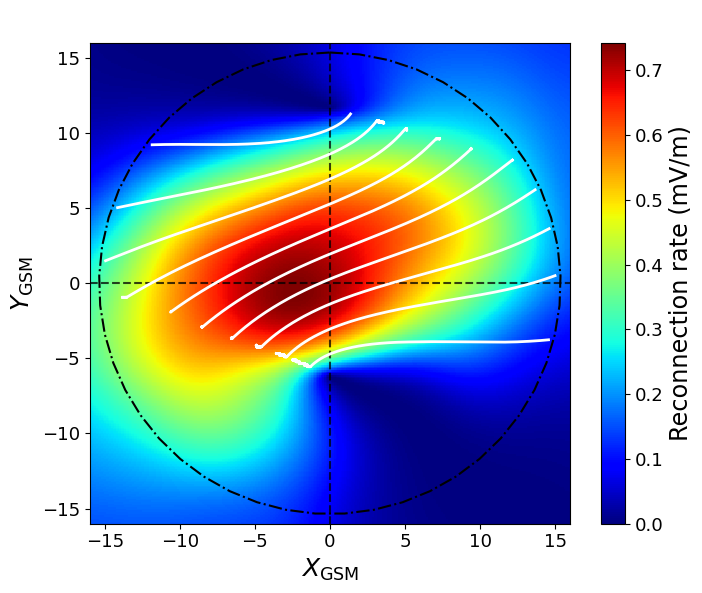

In [65]:
# On plot les potential Xlines

#cla, coa, tilt = 178, 85, -20
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
cbar.set_label('Reconnection rate (mV/m)', fontsize='xx-large')
fig.tight_layout()


for x0 in np.linspace(cusps[0]+1,cusps[1]-1,10):
#for x0 in list(np.linspace(-4,9,20)[3:-3]): #+list(np.linspace(0.5,4,10)):
    #xl = pd.read_pickle(f'/home/ghisalberti/komar_separators/potential_DXL_cla{cla}_coa90_tilt{tilt}_y0{round(x0,2)}_modified.pkl')
    xl = pd.read_pickle(f'/home/ghisalberti/komar_separators/potential_DXL_cla{cla}_coa90_tilt{tilt}_y0{round(x0,2)}.pkl')
        #ax[0].plot(xl['y'],xl['z'],c='w',lw=3)
    
    #xl = pd.read_pickle('/home/ghisalberti/komar_separators/potential_DXL_cla180_coa90_tilt-20_y0-4.0.pkl')
    ax[0].plot(xl['y'],xl['z'],lw=2, c='w',label=f'{round(x0,2)}')
    #ax[0].legend()
ax[0].set_xlabel(r'$X_{\text{GSM}}$')
ax[0].set_ylabel(r'$Y_{\text{GSM}}$')
#plt.savefig('/home/ghisalberti/Figures/potential_Xlines_DXL.png',bbox_inches='tight')

/tmp/ipykernel_118121/3937326652.py:16: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  rates += [integrate.quad(integrate_rate, 0,dl[-1],args=ir_dl)[0]]
/tmp/ipykernel_118121/3937326652.py:16: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  rates += [integrate.quad(integrate_rate, 0,dl[-1],args=ir_dl)[0]]
/tmp/ipykernel_118121/3937326652.py:16: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improv

ValueError: x and y must have same first dimension, but have shapes (10,) and (24,)

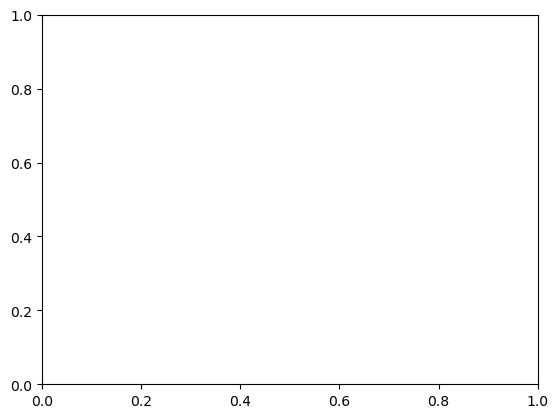

In [89]:
# On calcule les rate
cla=180
tilt=-20
rates = []
#x0s = np.linspace(cusps[0]+1,cusps[1]-1,10)
#for x0 in x0s:
for x0 in list(np.linspace(-4,9,20)[3:-3])+list(np.linspace(0.5,4,10)):
    xl = pd.read_pickle(f'/home/ghisalberti/komar_separators/potential_DXL_cla{cla}_coa90_tilt{tilt}_y0{round(x0,2)}_modified.pkl')
    #xl = pd.read_pickle(f'/home/ghisalberti/komar_separators/potential_DXL_cla{cla}_coa90_tilt{tilt}_y0{round(x0,2)}.pkl')
    dl = sm.norm(0,np.diff(xl['y']),np.diff(xl['z']))
    cond = ~np.isnan(dl)&(dl>0.01)
    xl = xl['y'][1:][cond],xl['z'][1:][cond]
    dl = np.nancumsum(dl[cond])
    ir = smap.make_linear_interpolator(yy,zz,rate)
    ir_dl = CubicSpline(dl, ir(xl[0],xl[1]))
    rates += [integrate.quad(integrate_rate, 0,dl[-1],args=ir_dl)[0]]
plt.plot(x0s, rates)

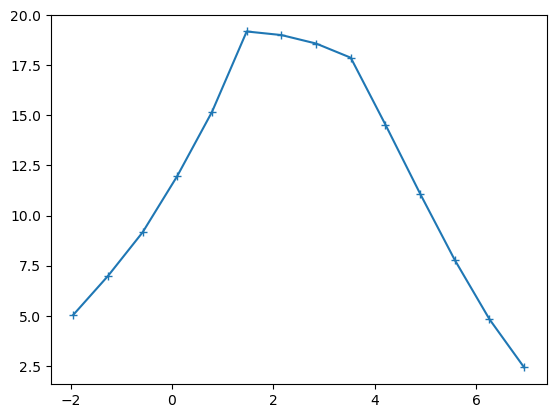

In [15]:
plt.plot(np.linspace(-4,9,20)[3:-3], rates, marker='+')


In [ ]:
plt.scatter(list(np.linspace(-4,9,20)[3:-3])+list(np.linspace(0.5,4,10)), rates)

In [83]:
np.sort(np.array([list(np.linspace(-4,9,20)[3:-3])+list(np.linspace(0.5,4,10))]))

array([[-1.94736842, -1.26315789, -0.57894737,  0.10526316,  0.5       ,
         0.78947368,  0.88888889,  1.27777778,  1.47368421,  1.66666667,
         2.05555556,  2.15789474,  2.44444444,  2.83333333,  2.84210526,
         3.22222222,  3.52631579,  3.61111111,  4.        ,  4.21052632,
         4.89473684,  5.57894737,  6.26315789,  6.94736842]])

In [87]:
len(rates)

10

In [88]:
len(list(np.linspace(-4,9,20)[3:-3])+list(np.linspace(0.5,4,10)))

24

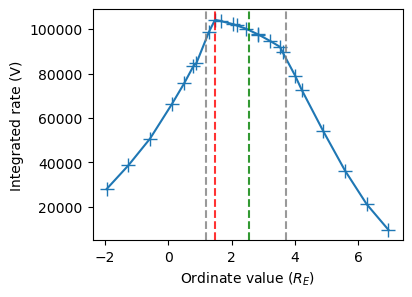

In [90]:
plt.figure(figsize=(4,3))
df = pd.DataFrame(np.array([list(np.linspace(-4,9,20)[3:-3])+list(np.linspace(0.5,4,10)),rates]).T, columns = ['y0','rate'])
df = df.sort_values(by='y0')
plt.plot(df.y0.values, df.rate.values*6.4*10**3, marker='+', markersize=10)
plt.axvline(1.2, color='gray',linestyle='--',alpha=0.8)
plt.axvline(3.7, color='gray',linestyle='--',alpha=0.8)
plt.axvline(1.473, color='red',linestyle='--',alpha=0.8)
plt.axvline(2.54, color='green',linestyle='--',alpha=0.8)
plt.xlabel(r'Ordinate value ($R_E$)')
plt.ylabel('Integrated rate (V)')
plt.savefig('/home/ghisalberti/Figures/rate_potential_DXL.png',bbox_inches='tight')

In [33]:
mV/m*Re

10**3V/m*6.4*10**6m = 6.4*10**9 V

,y0,rate
0,-1.947368,5.042531
1,-1.263158,6.983520
2,-0.578947,9.166033
3,0.105263,11.978199
4,0.789474,15.175619
5,1.473684,19.188380
6,2.157895,19.010227
7,2.842105,18.586876
8,3.526316,17.878813
9,4.210526,14.536695


In [188]:
# For dominant xline

#cla, tilt, coa = 120, -10, 90
#cla, tilt, coa = 165, 0, 90
#cla, tilt, coa = 120, -20, 90
#cla, tilt, coa = 120, -10, 90
#cla, tilt, coa = 120, 0, 90
#cla, tilt, coa = 120, 10, 90
#cla, tilt, coa = 120, 20, 90
#cla, tilt, coa, cusps = 180, -20, 90, [-5,8]   # PB avec celle-là!!
#cla, tilt, coa, cusps = 180, -10, 90, [-6,7]   
#cla, tilt, coa, cusps = 180, 0, 90, [-7,7]
#cla, tilt, coa, cusps = 180, 10, 90, [-7,6]       # PB avec celle-là!!
#cla, tilt, coa, cusps = 180, 20, 90, [-8,5]

# J'ai juste fait les symmétriques pour ceux qui avaient des pb

#cla, tilt, coa = 135, 0, 90
#cla, tilt, coa = 105, 0, 90
#cla, tilt, coa = 90, 0, 90
#cla, tilt, coa = 75, 0, 90
#cla, tilt, coa = 60, 0, 90
cla, tilt, coa = 45, 0, 90
#cla, tilt, coa = 30, 0, 90


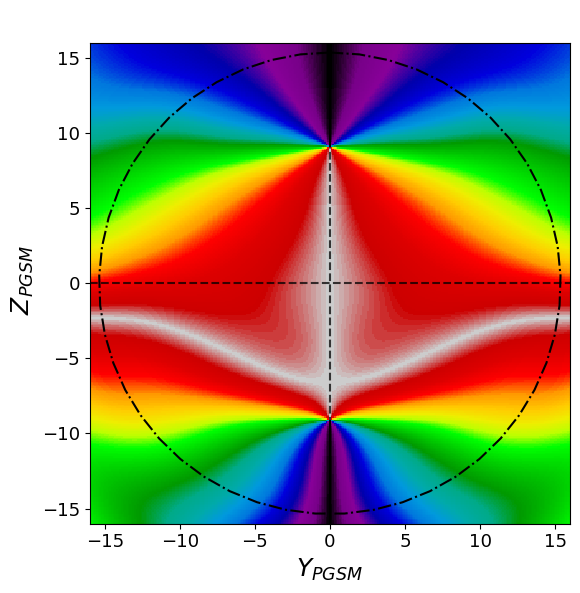

In [142]:
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
shear = make_shear(25,180,0)
c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))


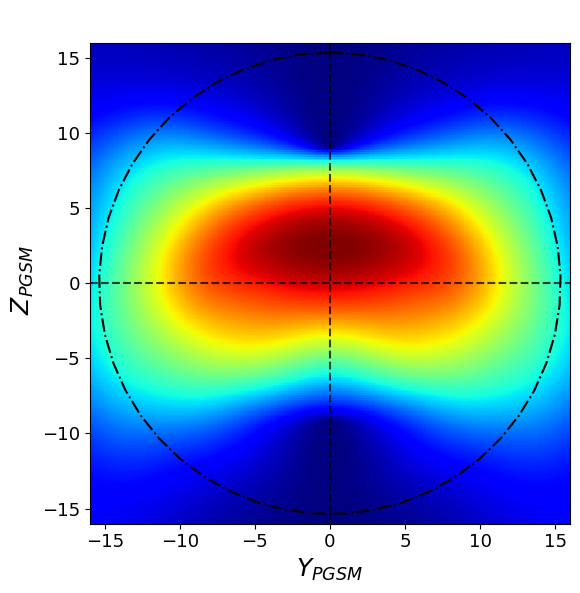

In [145]:
coa=25
cla=180
tilt = 0
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))

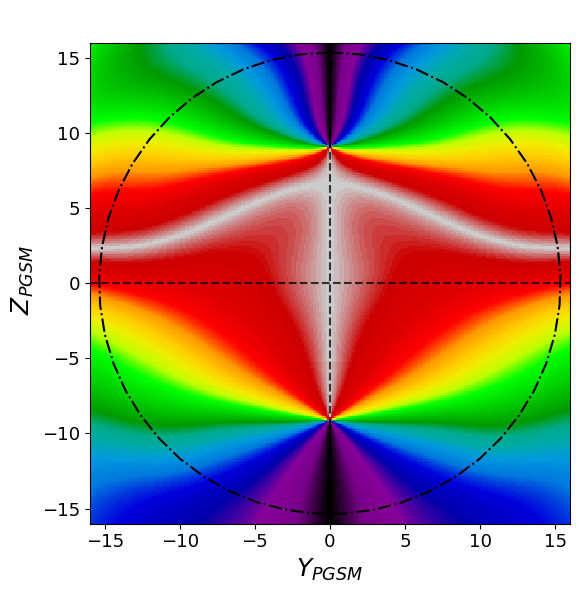

In [143]:
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
shear = make_shear(-25,180,0)
c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))


[-9.108  9.02 ]
[-8.608  8.52 ]
 message: Solution found.
 success: True
  status: 0
     fun: -80.93225212249374
       x: -1.7681595228447253
     nit: 20
    nfev: 20


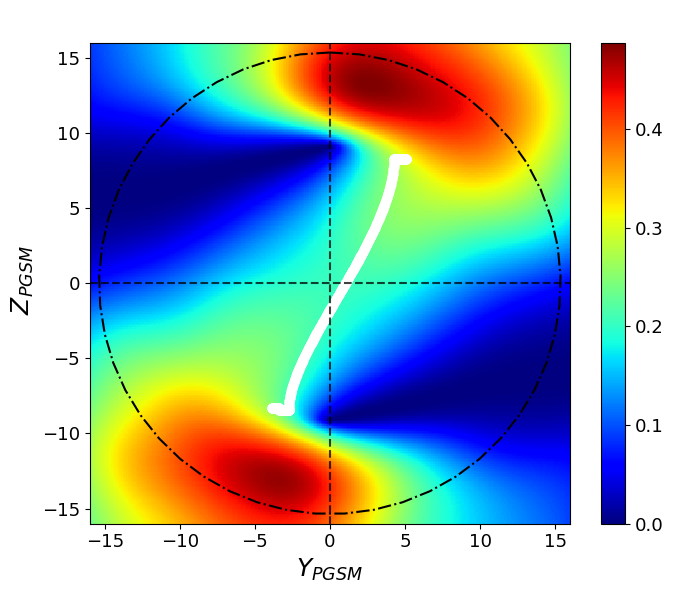

In [34]:
#cla, tilt, coa = 135, 0, -90
#cla, tilt, coa = 135, 0, -60
#cla, tilt, coa = 135, 0, -30
#cla, tilt, coa = 180, 0, -30
#cla, tilt, coa = 178, 0, -60
#cla, tilt, coa = 180, 0, -90
cla, tilt, coa = 60, 0, -88

rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
shear = make_shear(coa,cla,tilt)
a2d = su.reshape_to_2Darrays([yy, zz, vec[0],vec[1],rate,xx])[0]

if np.sign(cla)==1:
    cond = vec[0]<0 
    vec[0][cond] = -vec[0][cond]
    vec[1][cond] = -vec[1][cond]

a2d = su.reshape_to_2Darrays([yy, zz, vec[0],vec[1],rate,shear,xx])[0]
ixx = NearestNDInterpolator(a2d[:,:2], a2d[:,2])
iyy = NearestNDInterpolator(a2d[:,:2], a2d[:,3])
irr = NearestNDInterpolator(a2d[:,:2], a2d[:,4])
ish = NearestNDInterpolator(a2d[:,:2], a2d[:,5])
ix = NearestNDInterpolator(a2d[:,:2], a2d[:,6])

if cla!= 180:
    cusps = np.array(identify_cusps_z_position(yy,zz,shear))
    print(cusps)
    cusps = np.array([cusps.min()+0.5  ,cusps.max()-0.5  ])
else:
    cusps =[-9,9]
print(cusps)
x0 = minimize_scalar(to_maxmize_global_integrated_rate_along_z, 0, bounds=cusps,args =(ixx,iyy,irr,ish,cusps, 0.025,15))
#x0 = minimize_scalar(to_maxmize_global_integrated_rate, 0, bounds=cusps,args =(ixx,iyy,irr,ish,cusps, 0.025,15))
print(x0)

part1 = integrate_xline([ixx,iyy],ish,cusps,x0=0,y0=x0.x,fac=-1,rlim=15)
part2 = integrate_xline([ixx,iyy],ish,cusps,x0=0,y0=x0.x,fac=1,rlim=15)
xl  = np.concatenate([part1[0][::-1],part2[0]]),np.concatenate([part1[1][::-1],part2[1]])

fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

#c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
#ax[0].plot(xl[0],xl[1],c='w',lw=5)
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
plt.scatter(xl[0],xl[1],color='white')
pd.to_pickle({'CLA':cla,'COA':coa,'tilt':tilt,'y':xl[0], 'z':xl[1],'method':'DXL'}, f'/home/ghisalberti/komar_separators/DXL_cla_{cla}_coa_{coa}_tilt_{tilt}.pkl')

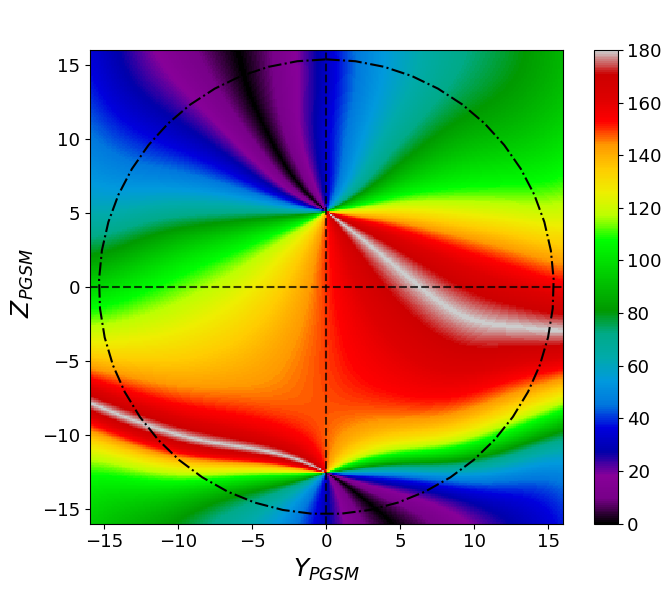

In [28]:
coa, cla, tilt = 90, 150, 30
shear = make_shear(coa,cla,tilt)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()


In [32]:
156+196+87+82

521

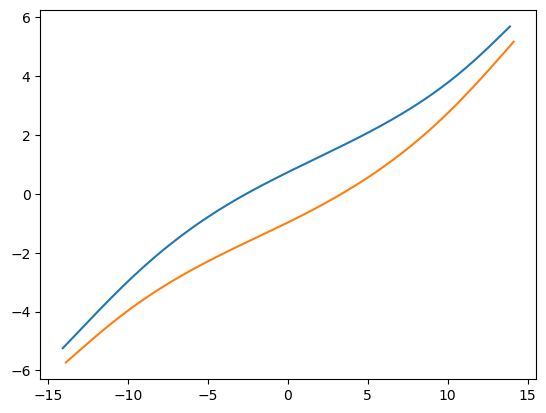

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
test = pd.read_pickle('/home/ghisalberti/komar_separators/DXL_cla_150_coa_-90_tilt_-10.pkl')
plt.plot(test['y'],test['z'])
test = pd.read_pickle('/home/ghisalberti/komar_separators/DXL_cla_150_coa_-90_tilt_10.pkl')
plt.plot(test['y'],test['z'])

In [ ]:
test = pd.read_pickle('/home/ghisalberti/komar_separators/DXL_cla_150_coa_-90_tilt_10.pkl')
plt.plot(test['y'],test['z'])

In [77]:
"""
y = xl[0][xl[0]<0]
z = xl[1][xl[0]<0]
y = np.array(list(y)+list(-y[::-1]))
z = np.array(list(z)+list(z[::-1]))
pd.to_pickle({'CLA':cla,'COA':coa,'tilt':tilt,'y':y, 'z':z,'method':'DXL'}, f'/home/ghisalberti/komar_separators/DXL_cla_{cla}_coa_{coa}_tilt_{tilt}.pkl')
"""

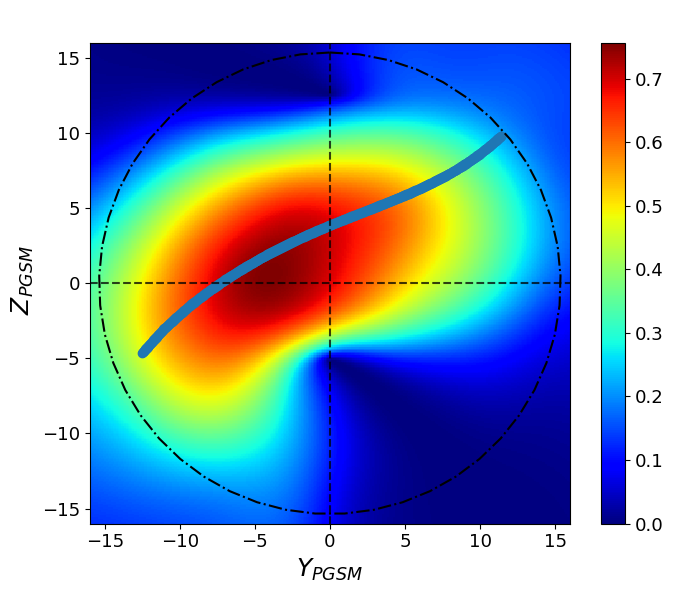

In [73]:
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

#c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
#ax[0].plot(xl[0],xl[1],c='w',lw=5)
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
plt.scatter(xl[0],xl[1])
pd.to_pickle({'CLA':cla,'COA':coa,'tilt':tilt,'y':xl[0], 'z':xl[1],'method':'DXL'}, f'/home/ghisalberti/komar_separators/DXL_cla_{cla}_coa_{coa}_tilt_{tilt}.pkl')

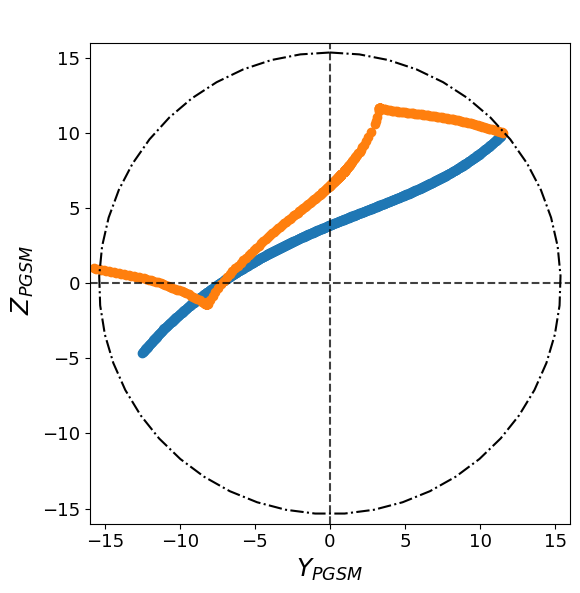

In [33]:
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
ax[0].scatter(xl[0],xl[1])
ax[0].scatter(msl[0],msl[1])


In [26]:
# For data max shear

cla, tilt, coa = 120, 0, 90


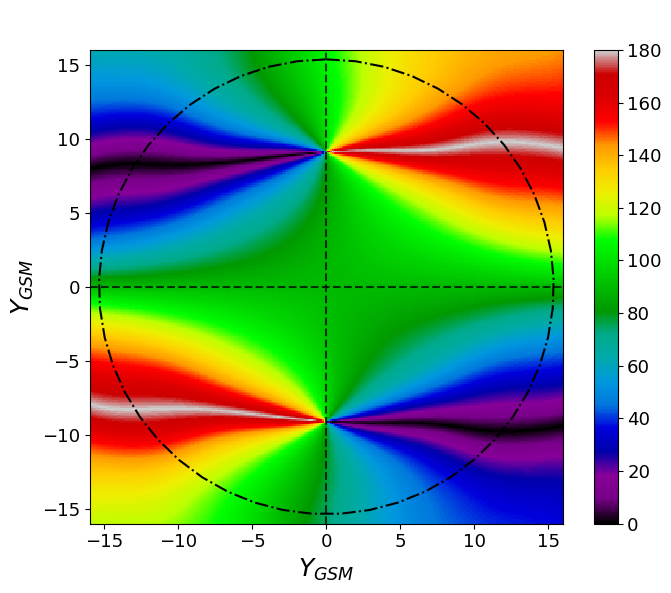

In [7]:
simu = 5
if simu == 1:
    cla, tilt, coa = 30, 15, 90
if simu == 2:
    cla, tilt, coa = 90, 15, -45
if simu == 3:
    cla, tilt, coa = 190, 0, 25
if simu == 4:
    cla, tilt, coa = 150, 0, 90
if simu==5:
    cla, tilt, coa = 90, 0, -45
    
shear = make_shear(coa,cla,tilt)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
ax[0].set_xlabel('$Y_{GSM}$')
ax[0].set_ylabel('$Y_{GSM}$')
fig.savefig(f'/home/ghisalberti/Figures/shear_simulation{simu}_bayane.png', bbox_inches='tight')

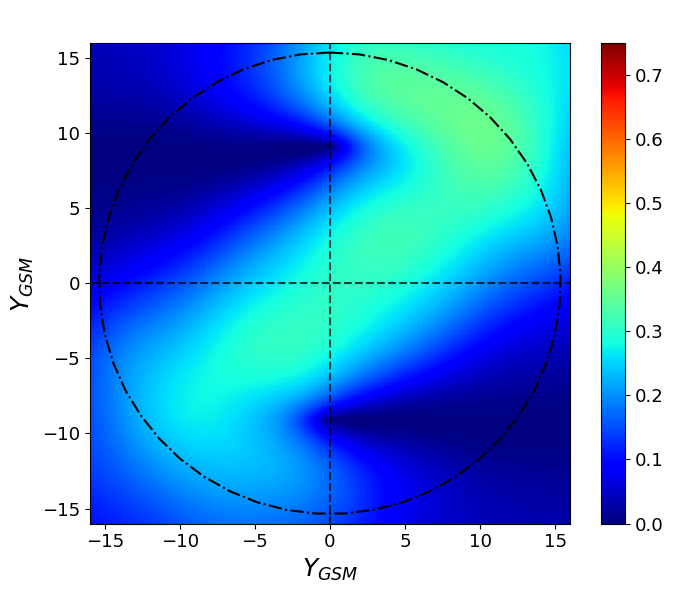

In [8]:
simu = 5
if simu == 1:
    cla, tilt, coa = 30, 15, 90
if simu == 2:
    cla, tilt, coa = 90, 15, -45
if simu == 3:
    cla, tilt, coa = 190, 0, 25
if simu == 4:
    cla, tilt, coa = 150, 0, 90
if simu==5:
    cla, tilt, coa = 90, 0, -45

rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
#c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,0.75))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
ax[0].set_xlabel('$Y_{GSM}$')
ax[0].set_ylabel('$Y_{GSM}$')
fig.savefig(f'/home/ghisalberti/Figures/rate_simulation{simu}_bayane.png', bbox_inches='tight')

Text(24.94555555555553, 0.5, '$Y_{GSM}$')

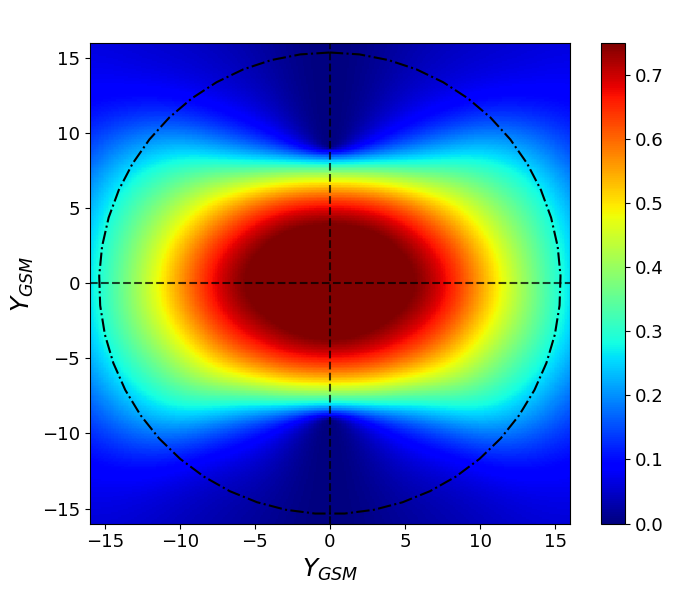

In [62]:
cla=180
coa = 90
tilt = 0
rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
#c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,0.75))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
ax[0].set_xlabel('$Y_{GSM}$')
ax[0].set_ylabel('$Y_{GSM}$')


Text(24.94555555555553, 0.5, '$Y_{GSM}$')

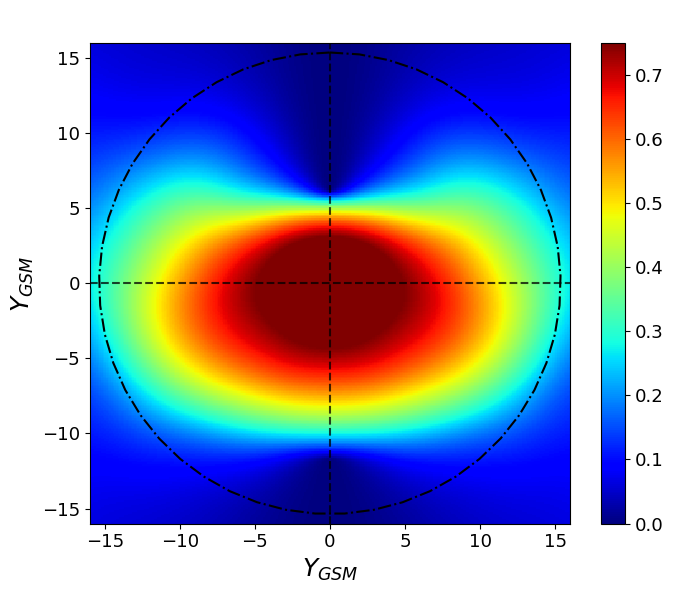

In [63]:
cla=180
coa = 90
tilt = 20
rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
#c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,0.75))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
ax[0].set_xlabel('$Y_{GSM}$')
ax[0].set_ylabel('$Y_{GSM}$')


/home/ghisalberti/Extraction_lines_bayane/shear_maps.py:473: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  Hrr, Hrc, Hcc  = hessian_matrix(qty )
/home/ghisalberti/Extraction_lines_bayane/shear_maps.py:451: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  eig1 ,eig2 =  hessian_matrix_eigvals(hessian_matrix(matrice_nn, sigma=np.std(matrice_nn)*0.01, order='rc'))


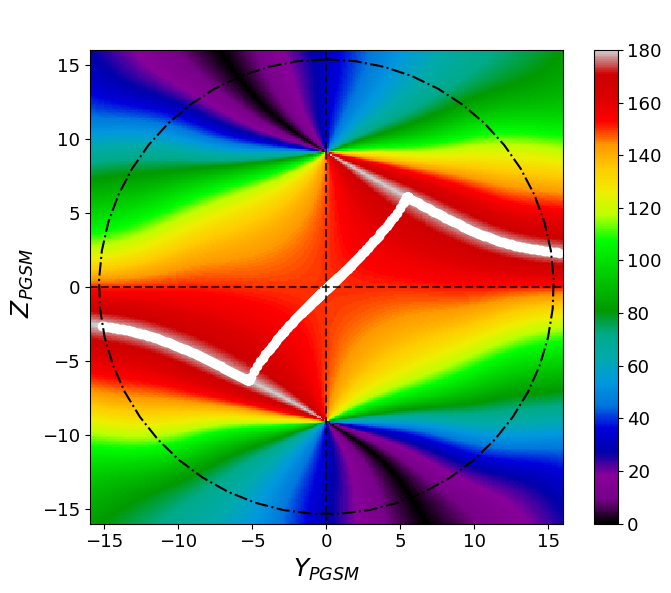

In [31]:
#cla, coa, tilt = 120, 90, -20
#cla, coa, tilt = 120, 90, -10
#cla, coa, tilt = 120, 90, 0
#cla, coa, tilt = 120, 90, 10
#cla, coa, tilt = 120, 90, 20
#cla, coa, tilt = 165, 90, 0
#cla, coa, tilt = 135, 90, 0
#cla, coa, tilt = 105, 90, 0
#cla, coa, tilt = 90, 90, 0
#cla, coa, tilt = 75, 90, 0
#cla, coa, tilt = 60, 90, 0
#cla, coa, tilt = 45, 90, 0
#cla, coa, tilt = 30, 90, 0

cla, coa, tilt = 150, 90, 0

shear = make_shear(coa,cla,tilt)
msl = smap.make_max_shear_line(yy,zz,shear)

fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
#c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
#ax[0].plot(xl[0],xl[1],c='w',lw=5)
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
plt.scatter(msl[0],msl[1],color='white')
#pd.to_pickle({'CLA':cla,'COA':coa,'tilt':tilt,'y':msl[0], 'z':msl[1],'method':'MSL'}, f'/home/ghisalberti/komar_separators/MSL_cla_{cla}_coa_{coa}_tilt_{tilt}.pkl')


/tmp/ipykernel_2400113/3321816885.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))


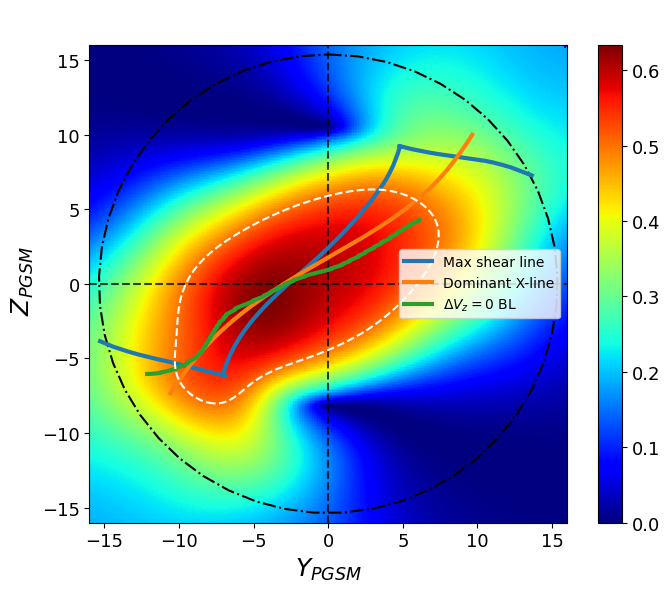

In [33]:
cla = 120
tilt = -10
coa = 90
rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()

coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/MSL_cla_{cla}_coa_90_tilt_{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label='Max shear line', linewidth=3)
coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/DXL_cla_{cla}_coa_90_tilt_{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label='Dominant X-line', linewidth=3)
coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/deltaVzBL_cla{cla}_tilt{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label=r'$\Delta V_z=0$ BL', linewidth=3)
ax[0].legend()
contour = ax[0].contour(yy,zz,rate,levels=[0.5],colors=['w'],linestyles=['--'])

/tmp/ipykernel_2400113/2128273626.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
/opt/conda/envs/space/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


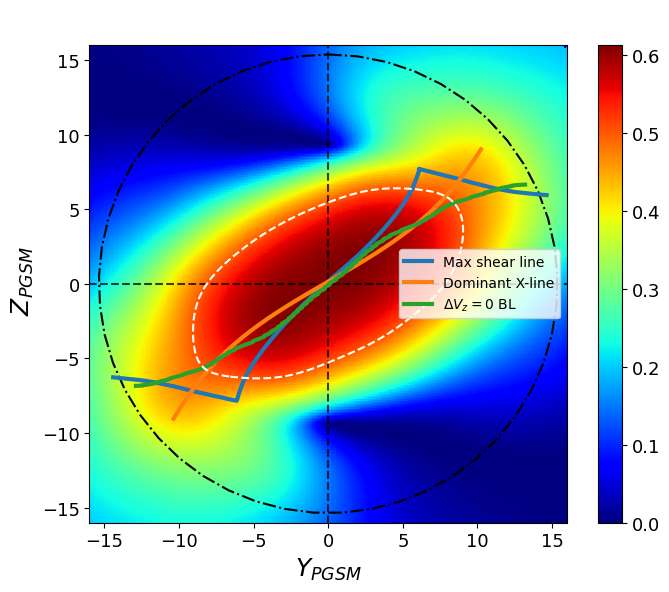

In [32]:
cla = 120
tilt = 0
coa = 90
rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()

coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/MSL_cla_{cla}_coa_90_tilt_{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label='Max shear line', linewidth=3)
coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/DXL_cla_{cla}_coa_90_tilt_{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label='Dominant X-line', linewidth=3)
coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/deltaVzBL_cla{cla}_tilt{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label=r'$\Delta V_z=0$ BL', linewidth=3)
ax[0].legend()
contour = ax[0].contour(yy,zz,rate,levels=[0.5],colors=['w'],linestyles=['--'])

/tmp/ipykernel_2400113/219837036.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))


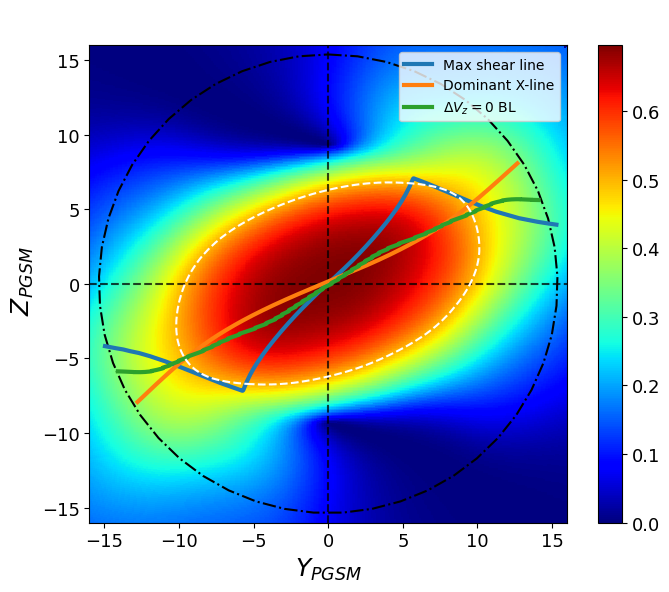

In [31]:
cla = 135
tilt = 0
coa = 90
rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()

coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/MSL_cla_{cla}_coa_90_tilt_{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label='Max shear line', linewidth=3)
coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/DXL_cla_{cla}_coa_90_tilt_{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label='Dominant X-line', linewidth=3)
coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/deltaVzBL_cla{cla}_tilt{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label=r'$\Delta V_z=0$ BL', linewidth=3)
ax[0].legend()
contour = ax[0].contour(yy,zz,rate,levels=[0.5],colors=['w'],linestyles=['--'])


/tmp/ipykernel_2400113/1497803899.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
/opt/conda/envs/space/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


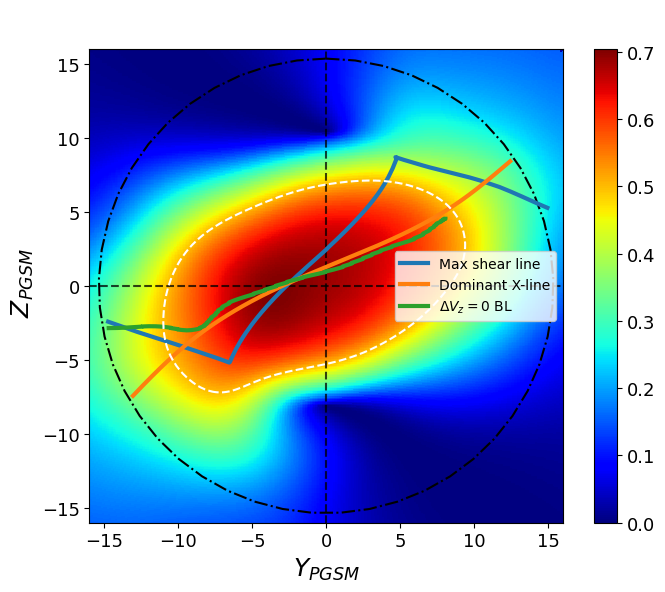

In [30]:
cla = 135
tilt = -10
coa = 90

rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()

dictio = pd.read_pickle('/home/ghisalberti/xline_models_cla_tlt.pkl')
y,z = dictio['MSL']['tilt'][str(tilt)]
ax[0].plot(y,z,label='Max shear line', linewidth=3)
y,z = dictio['DXL']['tilt'][str(tilt)]
ax[0].plot(y,z,label='Dominant X-line', linewidth=3)
coord = pd.read_pickle(f'/home/ghisalberti/komar_separators/deltaVzBL_cla{cla}_tilt{tilt}.pkl')
ax[0].plot(coord['y'],coord['z'],label=r'$\Delta V_z=0$ BL', linewidth=3)
ax[0].legend()
contour = ax[0].contour(yy,zz,rate,levels=[0.5],colors=['w'],linestyles=['--'])


In [22]:
contour.

array([0.5])

In [ ]:
!pip install --upgrade  scikit-image==0.19.3

/DATA/michotte/xline/shear_maps.py:473: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  Hrr, Hrc, Hcc  = hessian_matrix(qty )


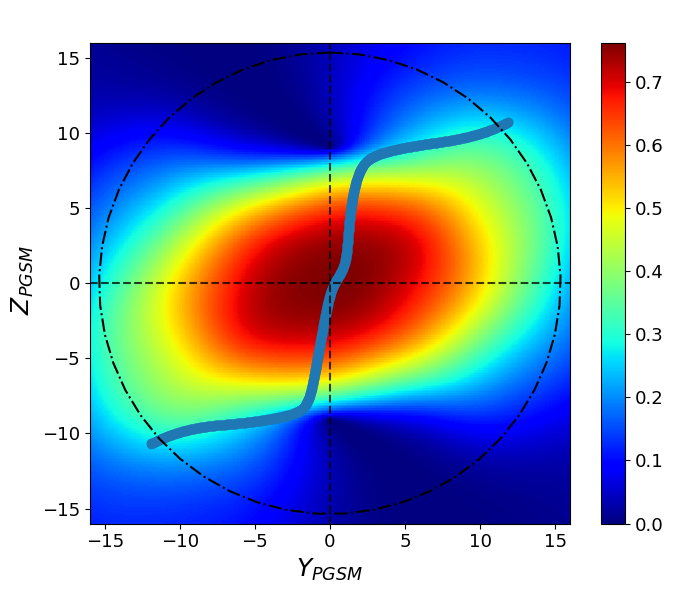

In [135]:
# Max rate

#cla, coa, tilt = 30, 90, 0
#cla, coa, tilt = 45, 90, 0
#cla, coa, tilt = 75, 90, 0
#cla, coa, tilt = 90, 90, 0
#cla, coa, tilt = 105, 90, 0
#cla, coa, tilt = 135, 90, 0
cla, coa, tilt = 150, 90, 0
#cla, coa, tilt = 165, 90, 0

rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=5,np_sw=5)
line = smap.make_max_qty_from_max_point(yy,zz,rate) #if only one max point 

fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

#c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
#ax[0].plot(xl[0],xl[1],c='w',lw=5)
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
plt.scatter(line[0],line[1])
pd.to_pickle({'CLA':cla,'COA':coa,'tilt':tilt,'y':line[0], 'z':line[1],'method':'max_rate'}, f'/home/ghisalberti/komar_separators/max_rate_cla_{cla}_coa_{coa}_tilt_{tilt}.pkl')


Pb: CLA = 165, COA = 90, tilt  0 donne ça...
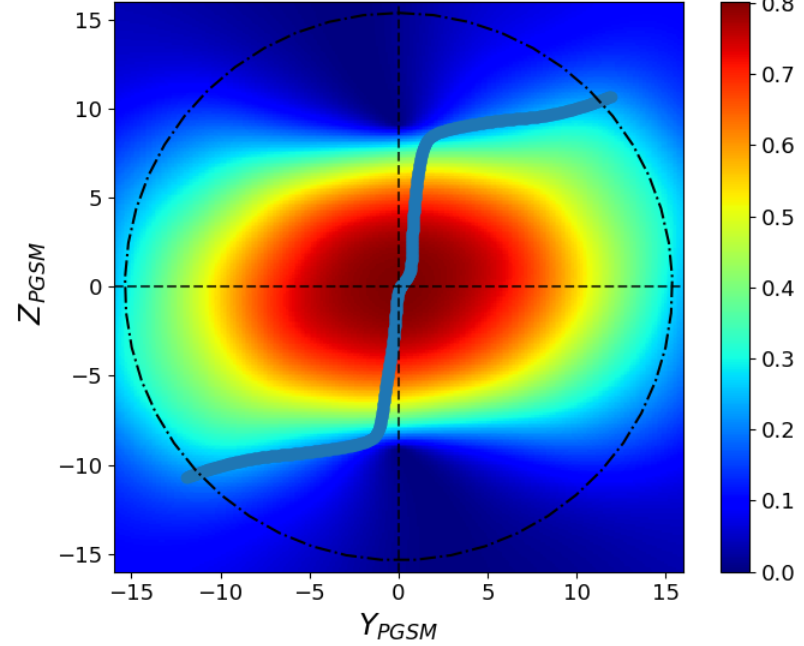

/home/ghisalberti/Extraction_lines_bayane/shear_maps.py:71: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  day_minutes = pd.date_range(day-timedelta(days=0.5),day+timedelta(days=0.5),freq=freq_day)
/opt/conda/envs/space/lib/python3.10/site-packages/spok/models/planetary.py:70: RuntimeWarning: divide by zero encountered in divide
  Bp = (1 / hp) * ((-B0y * np.sin(p) + B0z * np.cos(p)) * c * (s + s0 ** 2 / s) * t)
/opt/conda/envs/space/lib/python3.10/site-packages/spok/models/planetary.py:70: RuntimeWarning: invalid value encountered in multiply
  Bp = (1 / hp) * ((-B0y * np.sin(p) + B0z * np.cos(p)) * c * (s + s0 ** 2 / s) * t)
/home/ghisalberti/Extraction_lines_bayane/shear_maps.py:473: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  Hrr, Hrc, Hcc  = hessian_matrix(qty )
/home/ghisalberti/Extrac

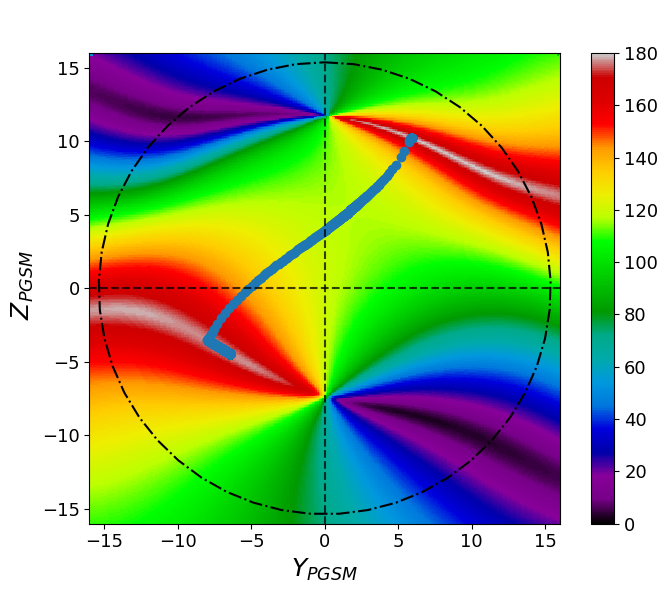

In [7]:
# Max shear with analytical models
from shear_maps import shear_map_t96_kf94

cla, coa, tilt =  120, 90, -20
#cla, coa, tilt =  120, 90, -10
#cla, coa, tilt =  120, 90, 0
#cla, coa, tilt =  120, 90, 10
#cla, coa, tilt =  120, 90, 20

bimf = 5
bximf,byimf,bzimf = bimf*np.cos(coa*np.pi/180), bimf*np.sin(coa*np.pi/180)*np.sin(cla*np.pi/180), bimf*np.sin(coa*np.pi/180)*np.cos(cla*np.pi/180)  # vérifier si les signes sont ok
date = smap.find_date_for_specific_tilt(tilt)
vsw = 400
dst = -9
ps = tilt*np.pi/180
xx,yy,zz,shear = shear_map_t96_kf94(theta,phi,date,1.65,vsw,bximf,byimf,bzimf,dst,ps,bs_model = smp.bs_jelinek2012)

msl = smap.make_max_shear_line_analytical(yy,zz,shear)

fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
#c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
#ax[0].plot(xl[0],xl[1],c='w',lw=5)
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
plt.scatter(msl[0],msl[1])
pd.to_pickle({'CLA':cla,'COA':coa,'tilt':tilt,'y':msl[0], 'z':msl[1],'method':'MSL_analytical'}, f'/home/ghisalberti/komar_separators/MSL_analytical_cla_{cla}_coa_{coa}_tilt_{tilt}.pkl')


In [42]:
failed_i = []
dxl_r = []
r_map = []
for i in range(len(events)):
    time= pd.to_datetime(events.iloc[i].start_time)+(pd.to_datetime(events.iloc[i].end_time)-pd.to_datetime(events.iloc[i].start_time))/2

    bx= events.iloc[i].Bx
    by= events.iloc[i].By
    bz=  events.iloc[i].Bz
    #vsw= 562.6 
    n =   events.iloc[i].n
    pdyn= events.iloc[i].P
    tilt = round(np.degrees(smp.get_tilt([time])[0]))
    if abs(tilt)>30:
        tilt = np.sign(tilt)*30
    cla = np.degrees(np.arctan2(by,bz))
    coa = round(np.degrees(np.arctan(np.sqrt(by**2+bz**2)/bx)))

    rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=sm.norm(bx,by,bz),np_sw=n)
    shear = make_shear(coa,cla,tilt)
    a2d = su.reshape_to_2Darrays([yy, zz, vec[0],vec[1],rate,xx])[0]

    if np.sign(cla)==1:
        cond = vec[0]<0 
        vec[0][cond] = -vec[0][cond]
        vec[1][cond] = -vec[1][cond]

    a2d = su.reshape_to_2Darrays([yy, zz, vec[0],vec[1],rate,shear,xx])[0]
    ixx = NearestNDInterpolator(a2d[:,:2], a2d[:,2])
    iyy = NearestNDInterpolator(a2d[:,:2], a2d[:,3])
    irr = NearestNDInterpolator(a2d[:,:2], a2d[:,4])
    ish = NearestNDInterpolator(a2d[:,:2], a2d[:,5])
    ix = NearestNDInterpolator(a2d[:,:2], a2d[:,6])
    try :
        cusps = np.array(identify_cusps_z_position(yy,zz,shear))
        cusps = np.array([cusps.min()+0.5  ,cusps.max()-0.5  ])
        x0 = minimize_scalar(to_maxmize_global_integrated_rate_along_z, 0, bounds=cusps,args =(ixx,iyy,irr,ish,cusps, 0.025,15))
        part1 = integrate_xline([ixx,iyy],ish,cusps,x0=0,y0=x0.x,fac=-1,rlim=15)
        part2 = integrate_xline([ixx,iyy],ish,cusps,x0=0,y0=x0.x,fac=1,rlim=15)
        xl  = np.concatenate([part1[0][::-1],part2[0]]),np.concatenate([part1[1][::-1],part2[1]])
        dxl_r.append([xl,irr(xl[0],xl[1])])
        r_map.append(rate)
        print(coa,round(cla), tilt,round(sm.norm(bx,by,bz),1),irr(xl[0],xl[1]).mean())
    except:
        print(i,' failed')
        failed_i.append(i)

NameError: name 'events' is not defined

In [161]:

val = np.array([])
for i in range(len(events)):
    by= events.iloc[i].By
    bz=  events.iloc[i].Bz
    cla = np.degrees(np.arctan2(by,bz))
    if (events.iloc[i].label=='ByDominant') :
        val = np.concat([val,dxl_r[i][-1]])

plt.figure()
h = plt.hist(val,bins=np.linspace(0,2.5,50),density=True,label='By Dominant',alpha=0.7)     


val = np.array([])
for i in range(len(events)):
    by= events.iloc[i].By
    bz=  events.iloc[i].Bz
    cla = np.degrees(np.arctan2(by,bz))
    if (events.iloc[i].label=='SouthwardIMF') :
        val = np.concat([val,dxl_r[i][-1]])
h = plt.hist(val,bins=np.linspace(0,2.5,50),density=True,label='Southward IMF',alpha=0.7)


val = np.array([])
for i in range(len(events)):
    by= events.iloc[i].By
    bz=  events.iloc[i].Bz
    cla = np.degrees(np.arctan2(by,bz))
    
    if (events.iloc[i].label=='NorthwardIMF') :
        #print(cla)
        #val = np.concat([val,r_map[i][r_map[i]>=np.percentile(r_map[i],0.999)]])
        val = np.concat([val,[r_map[i][(xx>=0) & (zz<=0)].max()]])
        #val = np.concat([val,r_map[i][(xx>=0) & (zz<=-9)]])
#h = plt.hist(val,bins=np.linspace(0,2.5,50),density=True,label='Northward IMF',alpha=0.7)

val = np.array([])
for i in range(len(events)):
    by= events.iloc[i].By
    bz=  events.iloc[i].Bz
    cla = np.degrees(np.arctan2(by,bz))
    
    if (events.iloc[i].label=='BigBx') :
        
        if abs(cla)>=60:
            print(cla,i)
            val = np.concat([val,dxl_r[i][-1]])
        else :
            
        #val = np.concat([val,r_map[i][r_map[i]>=np.percentile(r_map[i],0.999)]])
            val = np.concat([val,[r_map[i][(xx>=0) & (zz<=0)].max()]])
        #val = np.concat([val,r_map[i][(xx>=0) & (zz<=-9)]])

#h = plt.hist(val,bins=np.linspace(0,2.5,50),density=True,label='Big Bx',alpha=0.7)
plt.legend()

IndexError: invalid index to scalar variable.

In [118]:
dico  = {}
dico['map_coord'] = np.array([xx,yy,zz])
for i in range(len(events)):
    dico[events.iloc[i].start_time] = {'xline' : dxl_r[i][0], 'rate_xline': dxl_r[i][1], 'rate_map': r_map[i] }

In [120]:
#pd.to_pickle(dico,"tracers_events.pkl")

In [16]:
np.unique(events.label)

array(['BigBx', 'ByDominant', 'NorthwardIMF', 'SouthwardIMF'],
      dtype=object)

array([0.63569735, 0.63683545, 0.63789094, ..., 0.58168083, 0.58022938,
       0.57874531], shape=(60178,))

In [ ]:
smap.mp_sibeck1991_for_t96_tangents

In [9]:

time= pd.to_datetime('07/11/2025 17:32:00',dayfirst=True)

bx= -6.6
by= -4
bz=  2
#vsw= 562.6 
n =   4

tilt = round(np.degrees(smp.get_tilt([time])[0]))
cla = np.degrees(np.arctan2(by,bz))
coa = round(np.degrees(np.arctan(np.sqrt(by**2+bz**2)/bx)))
coa,cla, tilt,sm.norm(bx,by,bz)


(-34, np.float64(-63.43494882292201), -6, np.float64(7.972452571197899))

In [10]:
rate,theta,vec = make_bisec_reconnection_rate(coa,cla,tilt,bimf_norm=sm.norm(bx,by,bz),np_sw=n)
shear = make_shear(coa,cla,tilt)
a2d = su.reshape_to_2Darrays([yy, zz, vec[0],vec[1],rate,xx])[0]

In [11]:
if np.sign(cla)==1:
    cond = vec[0]<0 
    vec[0][cond] = -vec[0][cond]
    vec[1][cond] = -vec[1][cond]

In [12]:
a2d = su.reshape_to_2Darrays([yy, zz, vec[0],vec[1],rate,shear,xx])[0]
ixx = NearestNDInterpolator(a2d[:,:2], a2d[:,2])
iyy = NearestNDInterpolator(a2d[:,:2], a2d[:,3])
irr = NearestNDInterpolator(a2d[:,:2], a2d[:,4])
ish = NearestNDInterpolator(a2d[:,:2], a2d[:,5])
ix = NearestNDInterpolator(a2d[:,:2], a2d[:,6])

In [17]:
msl = smap.make_max_shear_line(yy,zz,shear)

/home/michotte/Postdoc_NPP/Collaborations/Da_Silva/../../../These/Python_function/My_functions/shear_maps.py:473: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  Hrr, Hrc, Hcc  = hessian_matrix(qty )
/home/michotte/Postdoc_NPP/Collaborations/Da_Silva/../../../These/Python_function/My_functions/shear_maps.py:451: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  eig1 ,eig2 =  hessian_matrix_eigvals(hessian_matrix(matrice_nn, sigma=np.std(matrice_nn)*0.01, order='rc'))


In [14]:
cusps = np.array(identify_cusps_z_position(yy,zz,shear))
print(cusps)
cusps = np.array([cusps.min()+1  ,cusps.max()-1  ])
#cusps =[-9,9]
print(cusps)
x0 = minimize_scalar(to_maxmize_global_integrated_rate_along_z, 0, bounds=cusps,args =(ixx,iyy,irr,ish,cusps, 0.025,15))
#x0 = minimize_scalar(to_maxmize_global_integrated_rate, 0, bounds=cusps,args =(ixx,iyy,irr,ish,cusps, 0.025,15))
print(x0)

part1 = integrate_xline([ixx,iyy],ish,cusps,x0=0,y0=x0.x,fac=-1,rlim=15)
part2 = integrate_xline([ixx,iyy],ish,cusps,x0=0,y0=x0.x,fac=1,rlim=15)
xl  = np.concatenate([part1[0][::-1],part2[0]]),np.concatenate([part1[1][::-1],part2[1]])

[-8.03    9.7625]
[-7.03    8.7625]
 message: Solution found.
 success: True
  status: 0
     fun: -103.9265203534575
       x: -3.4971752196376307
     nit: 18
    nfev: 18


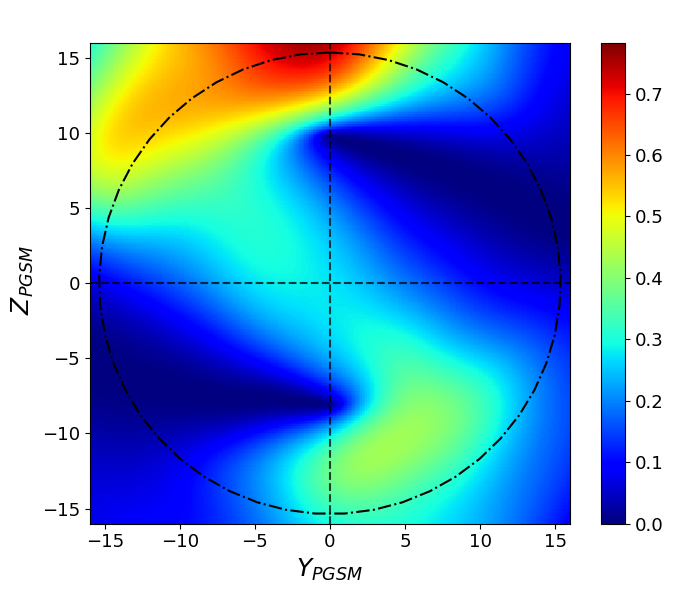

In [23]:
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
#ax[0].plot(xl[0],xl[1],c='w',lw=5)

cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
#fig.savefig('rate_DXL_model_Sur_event.png')
fig.savefig('rate_Sur_event.png')

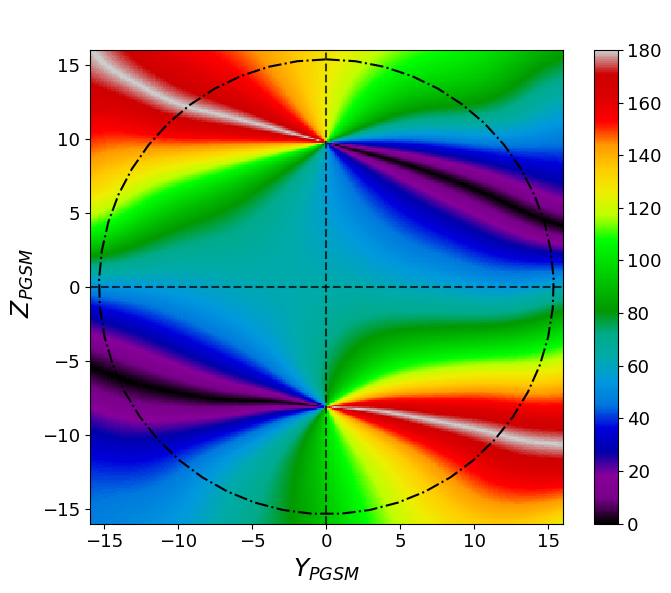

In [24]:
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

c = ax[0].pcolormesh(yy,zz, shear,cmap='nipy_spectral',norm=Normalize(0,180))
#ax[0].plot(xl[0],xl[1],c='w',lw=5)
#ax[0].plot(msl[0],msl[1],c='w',lw=5)
cbar = fig.colorbar(c,ax=ax[0])
cbar.ax.tick_params(labelsize=13) 
fig.tight_layout()
fig.savefig('shear_Sur_event.png')
#fig.savefig('shear_maxshear_model_Sur_event.png')

In [26]:
dico = pd.read_pickle('tracers_events.pkl')

In [27]:
events.labek

,start_time,end_time,Bx,By,Bz,score,file_name,direction,B,cone_angle,clock_angle,label,Sat,aci_file,ead_file,n,P
0,2025-09-26 15:44:51,2025-09-26 15:45:59,3.617883,-2.086126,-0.033694,0.660886,TracersDispersionEvent_TS2_2025-09-26T15:44:51...,forward,4.176378,29.971635,-90.925322,BigBx,TS2,data/MissionRun_TS2/aci/ts2_l2_aci_ipd_2025092...,data/MissionRun_TS2/ead/ts2_def_ead_20250926_v...,5.102500,1.778500
1,2025-09-26 17:21:45,2025-09-26 17:23:01,2.426667,-2.788000,0.445333,0.629675,TracersDispersionEvent_TS2_2025-09-26T17:21:45...,forward,3.722899,49.320904,-80.924686,ByDominant,TS2,data/MissionRun_TS2/aci/ts2_l2_aci_ipd_2025092...,data/MissionRun_TS2/ead/ts2_def_ead_20250926_v...,4.850000,1.710000
2,2025-09-26 18:58:01,2025-09-26 18:59:03,-0.288667,-3.400000,-2.509333,0.542606,TracersDispersionEvent_TS2_2025-09-26T18:58:01...,forward,4.235573,93.907903,-126.428779,ByDominant,TS2,data/MissionRun_TS2/aci/ts2_l2_aci_ipd_2025092...,data/MissionRun_TS2/ead/ts2_def_ead_20250926_v...,4.490000,1.670000
3,2025-09-26 23:44:40,2025-09-26 23:45:43,-3.639809,-2.297951,1.378799,0.778809,TracersDispersionEvent_TS2_2025-09-26T23:44:40...,reverse,4.519942,143.637093,-59.035723,BigBx,TS2,data/MissionRun_TS2/aci/ts2_l2_aci_ipd_2025092...,data/MissionRun_TS2/ead/ts2_def_ead_20250926_v...,5.946667,2.036667
4,2025-09-27 01:21:19,2025-09-27 01:22:37,-1.936180,-4.495037,0.769296,0.663395,TracersDispersionEvent_TS2_2025-09-27T01:21:19...,forward,4.954389,113.004350,-80.288295,ByDominant,TS2,data/MissionRun_TS2/aci/ts2_l2_aci_ipd_2025092...,data/MissionRun_TS2/ead/ts2_def_ead_20250927_v...,6.248500,2.003167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,2025-12-29 19:34:35,2025-12-29 19:35:31,-5.288823,-0.764492,2.173582,0.204452,TracersDispersionEvent_TS1_2025-12-29T19:34:35...,forward,5.768931,156.459372,-19.377789,BigBx,TS1,data/MissionRun_TS1/aci/ts1_l2_aci_ipd_2025122...,data/MissionRun_TS1/ead/ts1_pred_ead_20251229_...,6.991542,99.989998
106,2025-12-31 21:23:22,2025-12-31 21:24:16,2.271353,-7.550520,-0.595500,0.119233,TracersDispersionEvent_TS1_2025-12-31T21:23:22...,forward,7.907213,73.306562,-94.509511,ByDominant,TS1,data/MissionRun_TS1/aci/ts1_l2_aci_ipd_2025123...,data/MissionRun_TS1/ead/ts1_pred_ead_20251231_...,3.580000,1.440000
107,2026-01-01 18:20:59,2026-01-01 18:22:35,3.371789,-5.653930,-2.395607,0.593989,TracersDispersionEvent_TS1_2026-01-01T18:20:59...,forward,7.005342,61.228563,-112.962689,ByDominant,TS1,data/MissionRun_TS1/aci/ts1_l2_aci_ipd_2026010...,data/MissionRun_TS1/ead/ts1_pred_ead_20260101_...,4.779834,2.409833
108,2026-01-01 19:55:13,2026-01-01 19:56:23,3.203122,-5.783073,-2.693561,0.725009,TracersDispersionEvent_TS1_2026-01-01T19:55:13...,forward,7.138571,63.339287,-114.974521,ByDominant,TS1,data/MissionRun_TS1/aci/ts1_l2_aci_ipd_2026010...,data/MissionRun_TS1/ead/ts1_pred_ead_20260101_...,5.238278,23.709000


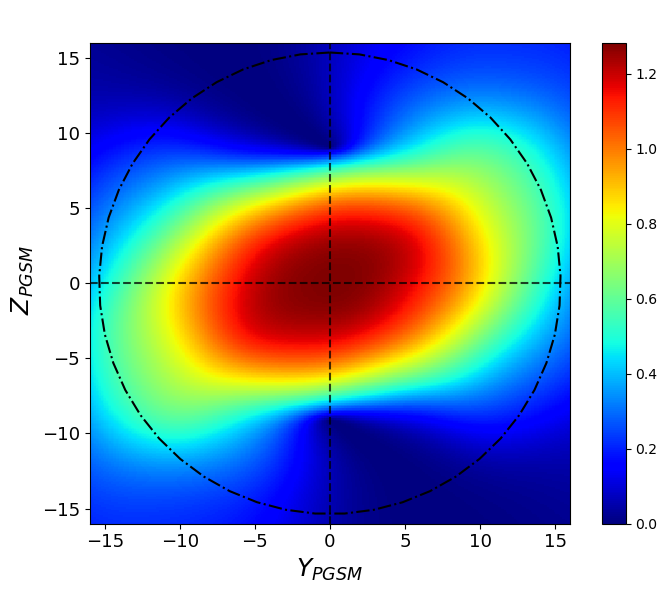

In [38]:
fig,ax = fig_nxm_plots(1,1,figsize=(7,6))

c = ax[0].pcolormesh(yy,zz, rate,cmap='jet',norm=Normalize(0,rate.max()))
cbar = fig.colorbar(c,ax=ax[0])

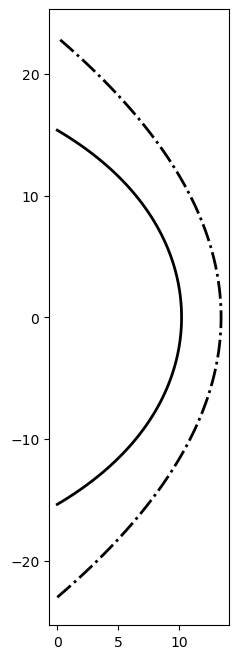

In [51]:
mp,bs = msh.boundaries(np.linspace(-np.pi/2,np.pi/2,100),0)
fig,ax = plt.subplots(figsize=(5,8))
ax.plot(mp[0],mp[2], color='k',lw=2)
ax.plot(bs[0],bs[2], color='k',ls='-.',lw=2)

ax.set_aspect('equal')

In [ ]:
dico = pd.read_pickle('tracers_events.pkl')

'2025-09-28 04:41:52'

In [70]:
northward_rate = []
start = []

i = 0
for i in range(sum(events.label == 'NorthwardIMF')):
    northward_rate.append(dico[events[events.label == 'NorthwardIMF'].start_time.iloc[i]]['rate_map'][zz<0].max())
    start.append(events[events.label == 'NorthwardIMF'].start_time.iloc[i])

In [75]:

northward_rate

[np.float64(0.7280055159501554),
 np.float64(1.5089252500606425),
 np.float64(1.3995694525720186),
 np.float64(0.399925087523828),
 np.float64(0.8239165341027654),
 np.float64(0.33472629743233756),
 np.float64(0.5355843141747316),
 np.float64(0.4538263836685787),
 np.float64(0.33429350380640593),
 np.float64(1.573937072468909),
 np.float64(0.8334682532537713),
 np.float64(0.576940643942949),
 np.float64(0.1612101971933133),
 np.float64(0.6872447560720901)]

In [74]:
df = pd.Series(index=pd.to_datetime(start),data=northward_rate)

In [76]:
df.to_csv('max_rate_southlobe_for_northwardIMF.csv')